# Log Odds Scoring System on KGB sample

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from matplotlib.ticker import PercentFormatter

# Find the project folder from the current working directory.
data_folder = Path("data") / "KGB Modelling"
project_root = next(
    (
        folder
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / data_folder / "KGB in sample.csv").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not find data/KGB Modelling/KGB in sample.csv "
        "from the current folder or its parents."
    )

data_path = project_root / data_folder / "KGB in sample.csv"
kgb_in_sample = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Accounts: {len(kgb_in_sample):,}")

Loaded: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB in sample.csv
Accounts: 7,258


---

## Defining the score scale

In [3]:
# An illustrative score scale:
# 600 points corresponds to 50:1 odds of good versus bad.
# Every 20 additional points doubles the good:bad odds.
base_score = 600
base_good_bad_odds = 50
points_to_double_odds = 20

factor = points_to_double_odds / np.log(2)
offset = base_score - factor * np.log(base_good_bad_odds)


def pd_to_score(probability):
    pd_values = np.asarray(probability, dtype=float)

    if not np.isfinite(pd_values).all():
        raise ValueError("Predicted PD contains a missing or infinite value.")
    if ((pd_values < 0) | (pd_values > 1)).any():
        raise ValueError("Predicted PD must be between 0 and 1.")

    # Prevent log(0) if the model returns an extreme probability.
    pd_values = np.clip(pd_values, 1e-12, 1 - 1e-12)
    good_bad_odds = (1 - pd_values) / pd_values

    return offset + factor * np.log(good_bad_odds)


print(f"Base score: {base_score} at {base_good_bad_odds}:1 good:bad odds")
print(f"Points to double good:bad odds: {points_to_double_odds}")

Base score: 600 at 50:1 good:bad odds
Points to double good:bad odds: 20


---

## Scoring the Accounts

In [5]:
# Prepare the same predictors used in the KGB cutoff notebook.
scaled = [
    "debt_to_income_ratio",
    "recent_application_count",
    "revolving_utilisation",
    "historic_defaults",
    "log_address_tenure",
]

train = kgb_in_sample.copy()
train["low_disposable_income_flag"] = (train["disposable_income"] < 150).astype(float)
train["log_address_tenure"] = np.log1p(train["time_at_address_months"])

means = train[scaled].mean()
stds = train[scaled].std(ddof=0)

x_train = (train[scaled] - means) / stds
x_train.insert(0, "const", 1.0)
x_train["low_disposable_income_flag"] = train["low_disposable_income_flag"]
x_train["loan_purpose=education"] = (train["loan_purpose"] == "education").astype(float)

y_train = train["target_bad"].astype(int)

model = sm.Logit(y_train, x_train.astype(float)).fit(maxiter=200, disp=False)
train_pd = model.predict(x_train)

train_scores = pd.DataFrame(
    {
        "predicted_pd": np.asarray(train_pd),
        "score": pd_to_score(train_pd),  # Function defined in Cell 1
        "observed_bad": np.asarray(y_train),
    }
)

display(
    train_scores.groupby("observed_bad")["score"]
    .agg(accounts="size", median_score="median")
    .rename(index={0: "Known good", 1: "Known bad"})
    .round(1)
)

,accounts,median_score
observed_bad,,
Known good,6964,582.8
Known bad,294,576.3


---

## Displaying the results

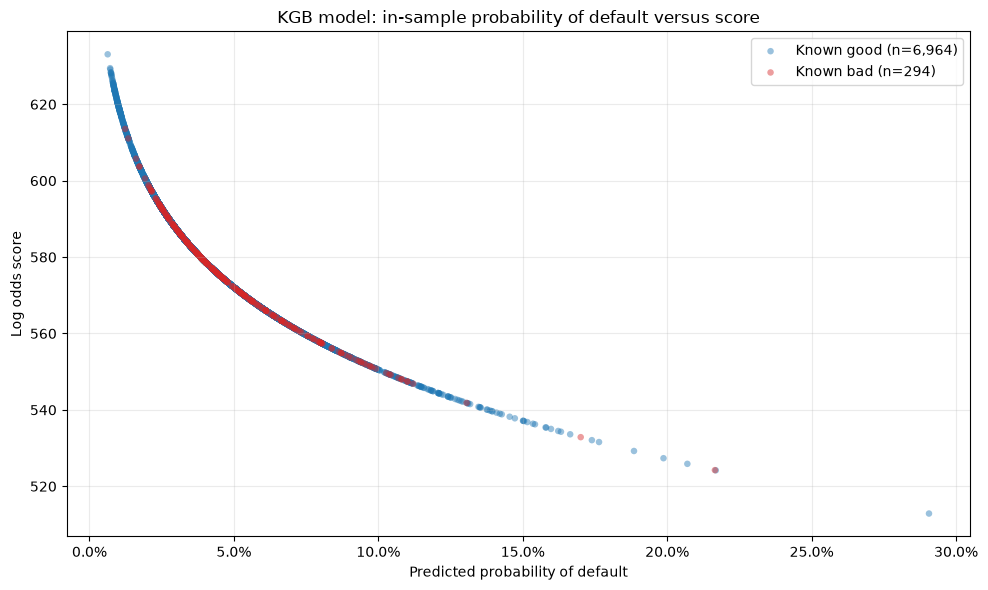

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for observed_bad, label, colour in [
    (0, "Known good", "tab:blue"),
    (1, "Known bad", "tab:red"),
]:
    group = train_scores.loc[train_scores["observed_bad"].eq(observed_bad)]

    ax.scatter(
        group["predicted_pd"],
        group["score"],
        label=f"{label} (n={len(group):,})",
        color=colour,
        alpha=0.45,
        s=22,
        edgecolors="none",
    )

ax.set(
    title="KGB model: in-sample probability of default versus score",
    xlabel="Predicted probability of default",
    ylabel="Log odds score",
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Adding the indeterminates and scoring them

In [8]:
indeterminate_path = project_root / "data" / "KGB Modelling" / "indeterminates.csv"

if not indeterminate_path.is_file():
    raise FileNotFoundError(indeterminate_path)

indeterminates = pd.read_csv(indeterminate_path)

print(f"Loaded: {indeterminate_path}")
print(f"Indeterminate accounts: {len(indeterminates):,}")

Loaded: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\indeterminates.csv
Indeterminate accounts: 197


---

## Applying the log odds score scale from the KGB model

In [11]:
# Use the transformations and training-data scaling parameters
# from the existing KGB model. Do not fit a new model here.
scoring_data = indeterminates.copy()

required = [
    "disposable_income",
    "time_at_address_months",
    "debt_to_income_ratio",
    "recent_application_count",
    "revolving_utilisation",
    "historic_defaults",
    "loan_purpose",
]
missing = sorted(set(required) - set(scoring_data.columns))
if missing:
    raise ValueError(f"Indeterminate data is missing: {missing}")

numeric = [column for column in required if column != "loan_purpose"]
scoring_data[numeric] = scoring_data[numeric].apply(pd.to_numeric, errors="raise")

if scoring_data[numeric].isna().any().any():
    raise ValueError("Indeterminate data contains missing model inputs.")
if scoring_data["time_at_address_months"].lt(0).any():
    raise ValueError("Address tenure cannot be negative.")

scoring_data["low_disposable_income_flag"] = (scoring_data["disposable_income"] < 150).astype(float)
scoring_data["log_address_tenure"] = np.log1p(scoring_data["time_at_address_months"])

# 'scaled', 'means', 'stds', and x_train come from the KGB fitting cell.
x_indeterminate = (scoring_data[scaled] - means) / stds
x_indeterminate.insert(0, "const", 1.0)
x_indeterminate["low_disposable_income_flag"] = scoring_data["low_disposable_income_flag"]
x_indeterminate["loan_purpose=education"] = (scoring_data["loan_purpose"] == "education").astype(
    float
)

# Match the exact column order used when fitting the model.
x_indeterminate = x_indeterminate[x_train.columns].astype(float)

indeterminate_pd = model.predict(x_indeterminate)

indeterminate_scores = scoring_data.copy()
indeterminate_scores["predicted_pd"] = np.asarray(indeterminate_pd)
indeterminate_scores["score"] = pd_to_score(indeterminate_pd)

---

## Plotting the Indeterminates with the known goods and bads

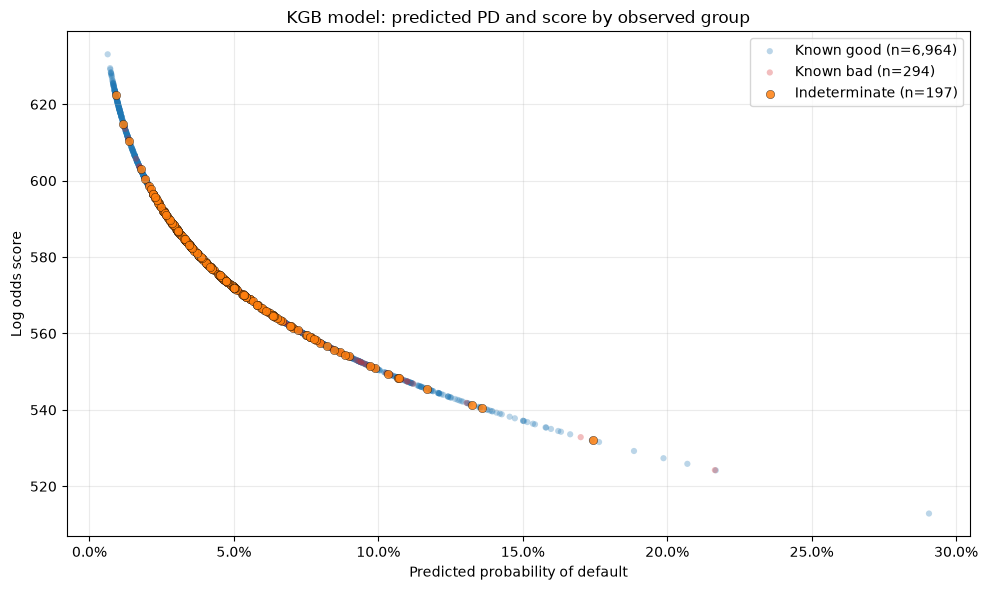

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

for observed_bad, label, colour in [
    (0, "Known good", "tab:blue"),
    (1, "Known bad", "tab:red"),
]:
    group = train_scores.loc[train_scores["observed_bad"].eq(observed_bad)]
    ax.scatter(
        group["predicted_pd"],
        group["score"],
        label=f"{label} (n={len(group):,})",
        color=colour,
        alpha=0.30,
        s=20,
        edgecolors="none",
    )

ax.scatter(
    indeterminate_scores["predicted_pd"],
    indeterminate_scores["score"],
    label=f"Indeterminate (n={len(indeterminate_scores):,})",
    color="tab:orange",
    alpha=0.85,
    s=36,
    edgecolors="black",
    linewidths=0.3,
)

ax.set(
    title="KGB model: predicted PD and score by observed group",
    xlabel="Predicted probability of default",
    ylabel="Log odds score",
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()